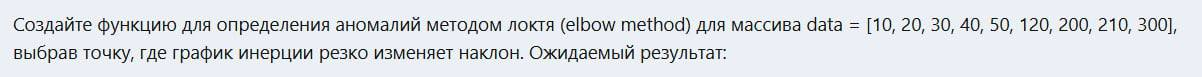

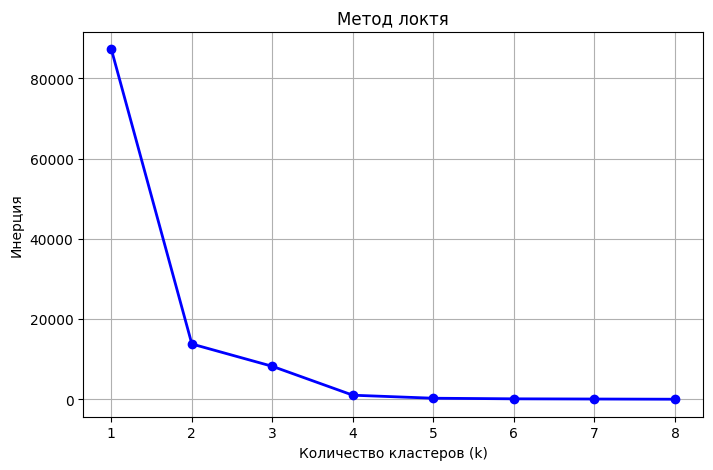

Оптимальное k (точка локтя): 3


In [2]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def find_elbow_point(data):
    # Преобразуем данные в 2D массив (sklearn требует)
    data_2d = np.array(data).reshape(-1, 1)
    
    inertias = []
    k_range = range(1, len(data))  # Проверяем k от 1 до n-1
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        kmeans.fit(data_2d)
        inertias.append(kmeans.inertia_)
    
    # Визуализация
    plt.figure(figsize=(8, 5))
    plt.plot(k_range, inertias, 'bo-', linewidth=2)
    plt.xlabel('Количество кластеров (k)')
    plt.ylabel('Инерция')
    plt.title('Метод локтя')
    plt.grid(True)
    plt.show()
    
    # Найдём точку "локтя" — где изменение инерции резко уменьшается
    # Простой способ: найти максимальную разницу вторых разностей (или просто посмотреть на график)
    # Для простоты — найдём k, где разница инерций падает больше всего
    deltas = np.diff(inertias)  # Разницы между соседними инерциями
    second_deltas = np.diff(deltas)  # Вторые разности
    
    # Индекс, где вторая разность минимальна (резкий излом)
    elbow_idx = np.argmin(second_deltas) + 2  # +2 потому что diff уменьшает длину
    
    print(f"Оптимальное k (точка локтя): {elbow_idx}")
    return elbow_idx

# Тест
data = [10, 20, 30, 40, 50, 120, 200, 210, 300]
optimal_k = find_elbow_point(data)

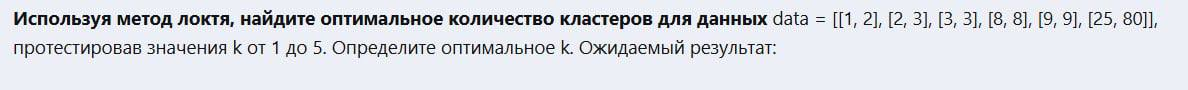

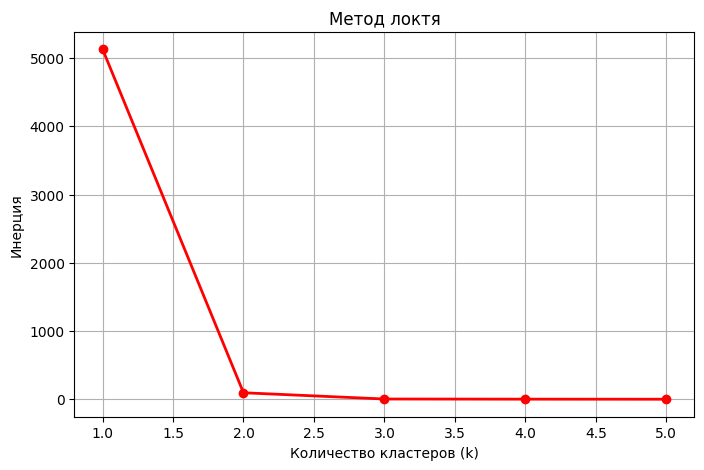

Оптимальное количество кластеров: 2


In [3]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def find_optimal_k(data, k_min=1, k_max=5):
    data_np = np.array(data)
    inertias = []
    k_values = list(range(k_min, k_max + 1))
    
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        kmeans.fit(data_np)
        inertias.append(kmeans.inertia_)
    
    # Построим график
    plt.figure(figsize=(8, 5))
    plt.plot(k_values, inertias, 'ro-', linewidth=2)
    plt.xlabel('Количество кластеров (k)')
    plt.ylabel('Инерция')
    plt.title('Метод локтя')
    plt.grid(True)
    plt.show()
    
    # Найдём "локоть" — обычно это точка, где график начинает "плоскнуть"
    # Можно просто посмотреть на график или найти максимум второй производной (упрощённо)
    # Здесь мы просто вернём k, где инерция падает меньше всего после этого
    deltas = np.diff(inertias)
    # Находим k, где падение инерции становится минимальным (после локтя)
    elbow_k = k_values[np.argmin(deltas) + 1] if len(deltas) > 0 else k_values[0]
    
    print(f"Оптимальное количество кластеров: {elbow_k}")
    return elbow_k

# Тест
data = [[1, 2], [2, 3], [3, 3], [8, 8], [9, 9], [25, 80]]
optimal_k = find_optimal_k(data, 1, 5)

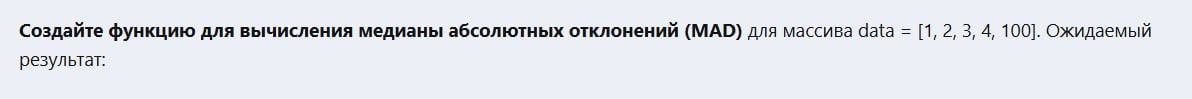

In [4]:
import numpy as np

def calculate_mad(data):
    data = np.array(data)
    median = np.median(data)
    abs_deviations = np.abs(data - median)
    mad = np.median(abs_deviations)
    return mad

# Тест
data = [1, 2, 3, 4, 100]
mad_result = calculate_mad(data)
print(f"MAD: {mad_result}")

MAD: 1.0


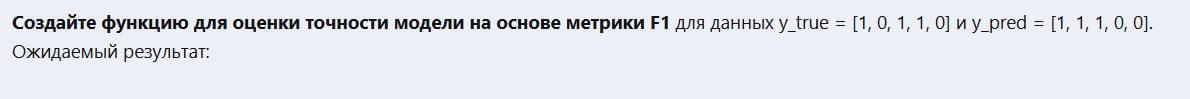

In [5]:
from sklearn.metrics import f1_score

def calculate_f1(y_true, y_pred):
    f1 = f1_score(y_true, y_pred)
    return f1

# Тест
y_true = [1, 0, 1, 1, 0]
y_pred = [1, 1, 1, 0, 0]
f1_result = calculate_f1(y_true, y_pred)
print(f"F1 score: {f1_result:.4f}")

F1 score: 0.6667


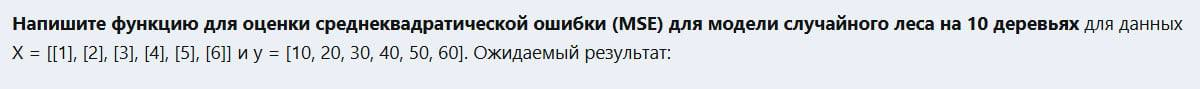

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

def calculate_mse_rf(X, y, n_trees=10):
    # Преобразуем в numpy массивы
    X = np.array(X)
    y = np.array(y)
    
    # Создаём и обучаем модель
    rf = RandomForestRegressor(n_estimators=n_trees, random_state=42)
    rf.fit(X, y)
    
    # Предсказываем
    y_pred = rf.predict(X)
    
    # Считаем MSE
    mse = mean_squared_error(y, y_pred)
    
    print(f"Предсказанные значения: {y_pred}")
    print(f"MSE: {mse:.4f}")
    return mse

# Тест
X = [[1], [2], [3], [4], [5], [6]]
y = [10, 20, 30, 40, 50, 60]
mse_result = calculate_mse_rf(X, y, 10)

Предсказанные значения: [15. 20. 28. 38. 46. 59.]
MSE: 8.3333
